# PART 1: Analysis on Palmer Penguins Dataset

## Task 1: Effect of outlier on mean and median

- Using the body_mass_g column from the Palmer Penguins dataset, demonstrate the
effect of an outlier by adding an extreme value, compare the mean and median before
and after the outlier, and write your observations based on the `results in your own
words as comments.

In [1]:
## Importing the Libraries

import pandas as pd
import seaborn as sns

In [2]:
## Loading the dataset

penguins_df = sns.load_dataset('penguins')

In [3]:
## Drop missing values

body_mass_g_clean = penguins_df['body_mass_g'].dropna()

In [4]:
## Calculating the mean() and median() before adding the outlier

mean_before = body_mass_g_clean.mean()
median_before = body_mass_g_clean.median()


In [5]:
## Append an extreme outlier

body_mass_g_modified = pd.concat([body_mass_g_clean, pd.Series([50000])])

In [6]:
## Calculating the mean() and median() after adding the outlier

mean_after = body_mass_g_modified.mean()
median_after = body_mass_g_modified.median()

In [7]:
## Displaying the results

print(f"Before Outlier - Mean: {mean_before:.3f}, Meadian: {median_before:.3f}")
print(f"After Outlier - Mean: {mean_after:.3f}, Meadian: {median_after:.3f}")


Before Outlier - Mean: 4201.754, Meadian: 4050.000
After Outlier - Mean: 4335.277, Meadian: 4050.000


#### Observations

1. The mean increases drastically after appending or adding an extreme outlier(from 4201.754 to 4335.277 approx.).
2. Meanwhile the median remains constant (from 4050.000 to 4050.000), illustrating that median is robust to extreme outliers.

## Task 2: Histrograms across different penguin species

- Using the flipper_length_mm column from the Palmer Penguins dataset, create
histograms to compare the distribution of flipper lengths across different penguin
species, and write your observations based on the visualization and results in your own
words as comments.

In [8]:
## Importing the Libraries

import matplotlib .pyplot as plt
import seaborn as sns

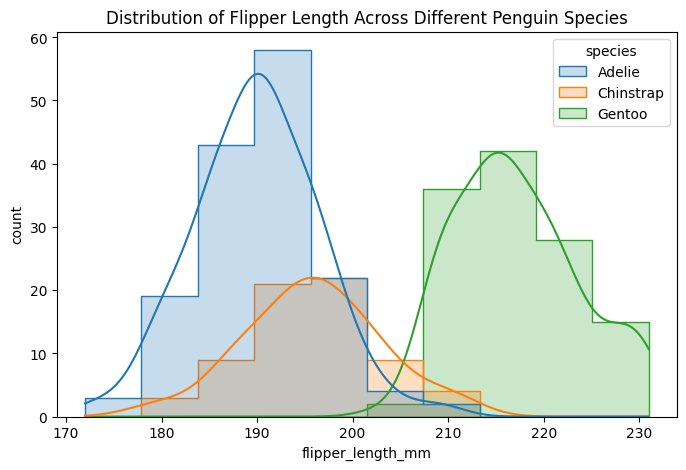

In [9]:
## Data Visualization by plotting histograms

plt.figure(figsize=(8, 5))
sns.histplot(
    data = penguins_df,
    x="flipper_length_mm",
    hue="species",
    element="step",
    kde=True
)
plt.title("Distribution of Flipper Length Across Different Penguin Species")
plt.xlabel("flipper_length_mm")
plt.ylabel("count")
plt.show()

#### Observations

1. Gentoo penguins have larger flipper lengths compared to Adelie and Chinstrap penguin species.
2. Adelie and Chinstrap having overlapping flipper length distributions centered around 190 mm.

## Task 3: Descriptive & Shape Statistics

- Using the body_mass_g column from the Palmer Penguins dataset, compare the
distribution of body mass across different penguin species by calculating the variance,
skewness, kurtosis, and Pearson's coefficients of skewness, and write your observations
based on the results in your own words as comments.

In [10]:
## Importing the Libraries

import pandas as pd
import seaborn as sns

In [11]:
## Grouping to calculate the distribution metrices

grouped_body_mass_g = penguins_df.groupby("species")["body_mass_g"]

In [12]:
## Variance, Skewness, Kurtosis

variance = grouped_body_mass_g.var()
skewness = grouped_body_mass_g.apply(lambda x: x.skew())
kurtosis = grouped_body_mass_g.apply(lambda x: x.kurtosis())

In [13]:
## pearson's coefficients of skewness

def pearson_coefficient_of_skewness(x):
  return 3 * (x.mean() - x.median())/x.std()

pearson_coefficient_of_skewness = grouped_body_mass_g.apply(pearson_coefficient_of_skewness)

In [14]:
## Summary statistics of the whole task

summary_stats = pd.DataFrame(
    {
        "Variance": variance,
        "Skewness": skewness,
        "Kurtosis": kurtosis,
        "Pearson Coefficient of Skewness": pearson_coefficient_of_skewness,
    }
)

print(summary_stats)

                Variance  Skewness  Kurtosis  Pearson Coefficient of Skewness
species                                                                      
Adelie     210282.891832  0.285336 -0.573738                         0.004333
Chinstrap  147713.454785  0.247433  0.593379                         0.258276
Gentoo     254133.180061  0.069635 -0.722791                         0.452373


#### Observations

1. Gentoo penguins have the highest variance in body mass, showing that there weights are far more spread out than Adelie and Chinstrap penguins.
2. All the species shows a slight positive skewness, showing a slight right-leaned tail towards the heavier penguins within each group.
3. Adelie(-0.57 approx) and Gentoo(-0.72 approx) are platykurtic, while Chinstrap is lepokurtic(0.59 approx).
4. All species having a positive pearson coefficients. Adelie coefficient is extremely close to zero(0.004 approx.) explaining that its mean and median body mass are almost identical.
Meanwhile Gentoo shows the highest relative gap(0.452 approx) between its mean and median relative to its standard deviation.

## Task 4: Five-Number Summary, IQR, and Grouped Boxplots

- Using the body_mass_g column from the Palmer Penguins dataset, calculate the fivenumber summary (minimum, Q1, median, Q3, and maximum), determine the
interquartile range (IQR), create grouped boxplots for each penguin species, and write
your observations based on the visualization and results in your own words as
comments.

In [15]:
## Importing the Libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
## Five-number summary across each penguin species

summary = grouped_body_mass_g.describe()[["min", "25%", "50%", "75%", "max"]]
summary["IQR"] = summary["75%"] - summary["25%"]

print(summary)

              min     25%     50%     75%     max    IQR
species                                                 
Adelie     2850.0  3350.0  3700.0  4000.0  4775.0  650.0
Chinstrap  2700.0  3487.5  3700.0  3950.0  4800.0  462.5
Gentoo     3950.0  4700.0  5000.0  5500.0  6300.0  800.0


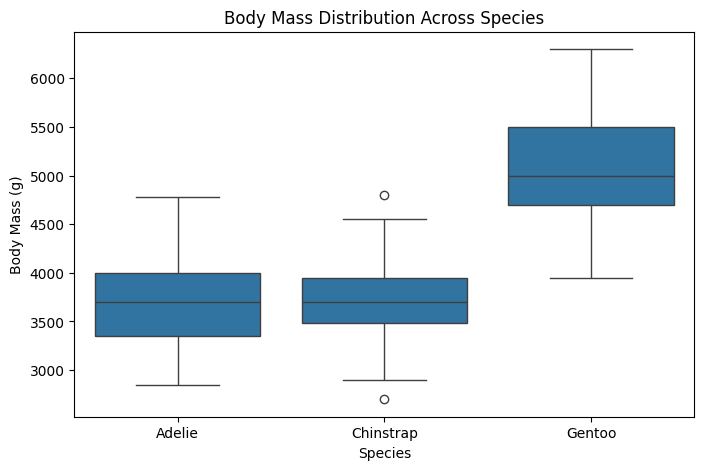

In [17]:
## Grouped Boxplot

plt.figure(figsize=(8,5))
sns.boxplot(data = penguins_df, x="species", y="body_mass_g")
plt.title("Body Mass Distribution Across Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

#### Observations

1. Gentoo species have a significantly higher median bosy mass(5000 approx.) and broader IQR comparitively Adelie and Chinstrap(3700 approx.).
2. Boxplots highlight structural shift in center and spread across categories clearly.


## Task 5: Linear Correlation & Regression

- Using the flipper_length_mm and body_mass_g columns from the Palmer Penguins
dataset, create a scatter plot, fit a linear regression line, calculate the covariance and
Pearson correlation coefficient, and write your observations based on the visualization
and results in your own words as comments.



In [18]:
## Importing the libraries

import matplotlib.pyplot as plt
import seaborn as sns


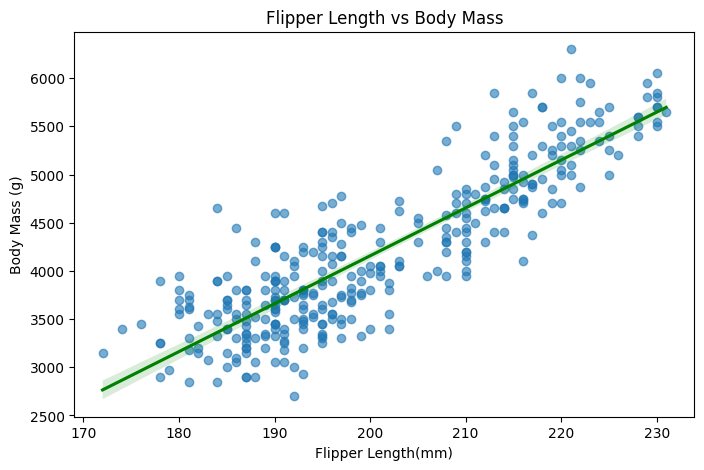

In [19]:
## Plotting a Scatter Plot

plt.figure(figsize=(8, 5))
sns.regplot(
    data = penguins_df,
    x = "flipper_length_mm",
    y = "body_mass_g",
    scatter_kws= {"alpha": 0.6},
    line_kws={"color": "green"},
)
plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length(mm)")
plt.ylabel("Body Mass (g)")
plt.show()

In [20]:
## Covariance and Correlation

covariance = penguins_df["flipper_length_mm"].cov(penguins_df["body_mass_g"])
pearson_correlation_coefficient = penguins_df["flipper_length_mm"].corr(penguins_df["body_mass_g"])

print(f"Covariance: {covariance:.3f}")
print(f"Pearson Correlation Coefficient: {pearson_correlation_coefficient:.3f}")

Covariance: 9824.416
Pearson Correlation Coefficient: 0.871


#### Observations

1. Pearson Correlation Coefficient(0.871 approx.) shows a strong positive linear correlation between flipper length and bosy mass.
2. Large positive value of covariance(9824.416 approx) confirms that both the metrices increase together.
3. The regression line shows a clear upward trajectory across the range.
4. Data points form two major clusters(190 mm approx. and 215mm approx.) which highlights inherent size distinctions between species.

## Task 6: Biomass Supported by Each Island

- Using the body_mass_g column from the Palmer Penguins dataset, group the data based
on the island column and calculate the total penguin biomass supported by each island.
Create a pie chart to show the proportion of total biomass contributed by each island
and a bar chart to compare the absolute total biomass values. Write your observations
based on the visualization and results in your own words as comments.



In [21]:
## Import the libraries

import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
## Group the dataset to calculate the total penguin biomass per island

island_biomass = penguins_df.groupby("island")["body_mass_g"].sum()

<function matplotlib.pyplot.show(close=None, block=None)>

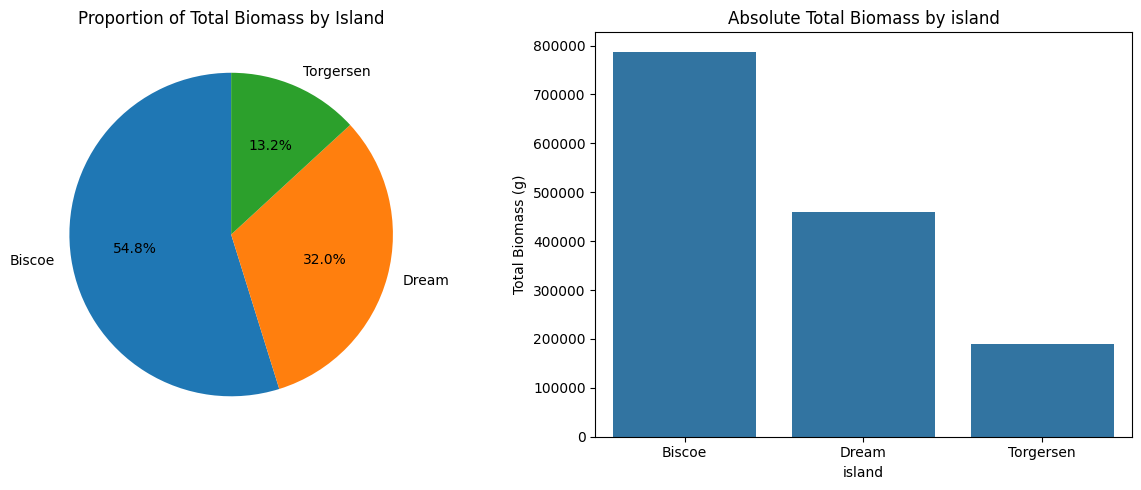

In [23]:
## Initialize a figure layout to draw the plots

fig, axes = plt.subplots(1, 2, figsize=(12,5))

## Draw Pie Chart
axes[0].pie(
    island_biomass,
    labels = island_biomass.index,
    autopct = "%1.1f%%",
    startangle = 90,
)
axes[0].set_title("Proportion of Total Biomass by Island")

## Draw Bar Chart
sns.barplot(
    x=island_biomass.index, y= island_biomass.values, ax=axes[1]
)
axes[1].set_title("Absolute Total Biomass by island")
axes[1].set_ylabel("Total Biomass (g)")

plt.tight_layout()
plt.show


#### Observations

1. Biscoe island supports the vast majority of biomass, primarily due to hosting larger Gentoo penguins.
2. Torgersen island supports the smallest total biomass share.

## Task 7: Multivariable Scatter Plot

- Using the bill_length_mm and bill_depth_mm columns from the Palmer Penguins
dataset, investigate whether the relationship between bill length and bill depth varies
across different penguin species. Create a scatter plot with different colors representing
each species to identify species-specific patterns and relationships. Write your
observations based on the visualization and results in your own words as comments.


In [24]:
## Importing the Libraries

import matplotlib.pyplot as plt
import seaborn as sns

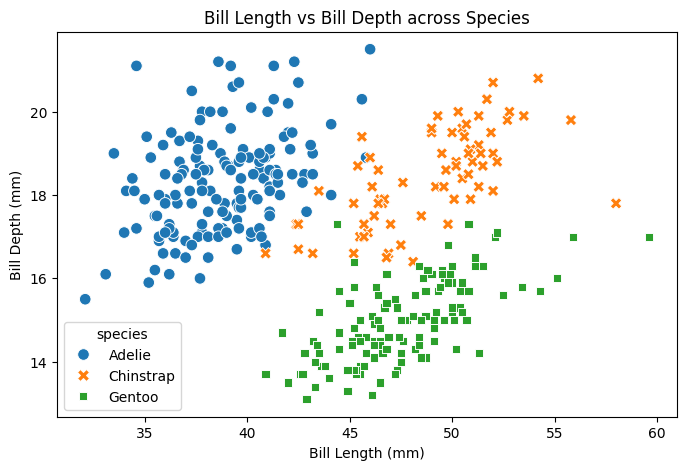

In [25]:
## Drawing the plot

plt.figure(figsize=(8,5))
sns.scatterplot(
    data = penguins_df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
    s=70,
)
plt.title("Bill Length vs Bill Depth across Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

#### Observations

1. Shows a classic case of Simpson's Paradox: overall data suggests a negative relationship, but within each species, length and depth correlate positively.
2. Species form distinct clusters on the bill length vs depth plane.

# PART 2: Analysis on Dow Jones Time-Series Dataset

## Task 1: Decade Based Price Distributions

- Using the Price column from the Dow Jones dataset, calculate the five-number
summary (minimum, Q1, median, Q3, and maximum) and determine the interquartile
range (IQR). Group the data using the engineered Decade column and create boxplots
to compare the distribution, spread, and median price values across different decades.
Write your observations based on the visualization and results in your own words as
comments.

In [26]:
## Import the Libraries

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [27]:
## Loading the dataset

df = sns.load_dataset("dowjones")

In [28]:
## Five number summary & IQR

min_val = df["Price"].min()
q1_val = df["Price"].quantile(0.25)
median_val = df["Price"].median()
q3_val = df["Price"].quantile(0.75)
max_val = df["Price"].max()
iqr_val = q3_val - q1_val

print(f"Min: {min_val}, \nQ1: {q1_val}, \nMedian: {median_val}, \nQ3: {q3_val}, \nMax: {max_val}, \nIQR: {iqr_val}")

Min: 46.85, 
Q1: 106.9, 
Median: 172.27, 
Q3: 436.73, 
Max: 985.93, 
IQR: 329.83000000000004


In [29]:
## Feature engineering decade

df["Date"] = pd.to_datetime(df["Date"])
df["Decade"] = ((df["Date"].dt.year // 10) * 10).astype(str) + "s"

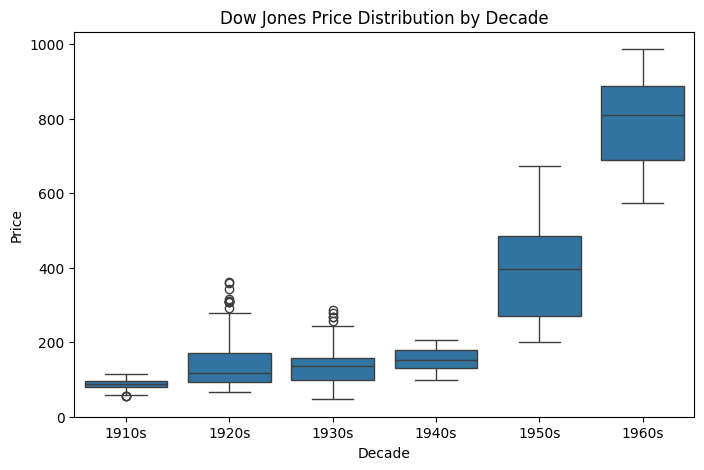

In [30]:
## Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Decade", y ="Price")
plt.title("Dow Jones Price Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("Price")
plt.show()

#### Observations

1. Both median index prices and spread (IQR) expand significantly across successive decades.

## Task 2: Time Series Trend & Linear Regression

- Using the Date and Price columns from the Dow Jones dataset, create a time-series line
plot to visualize the change in index prices over time. Convert dates into numerical
values and fit a linear regression model to identify the overall trend in the data. Display
the regression trendline along with the original time-series data, calculate the Pearson
correlation coefficient and R-squared value, and write your observations based on the
visualization and results in your own words as comments.

In [31]:
## Importing the Libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [32]:
## Convert Date to numerical values

df["Date_Num"] = df["Date"].map(pd.Timestamp.toordinal)

In [33]:
## Linear Regression

slope, intercept, r_value, p_value, std_err = stats.linregress(df["Date_Num"], df["Price"])
df["Trendline"] = intercept + slope * df["Date_Num"]
r_squared = r_value**2

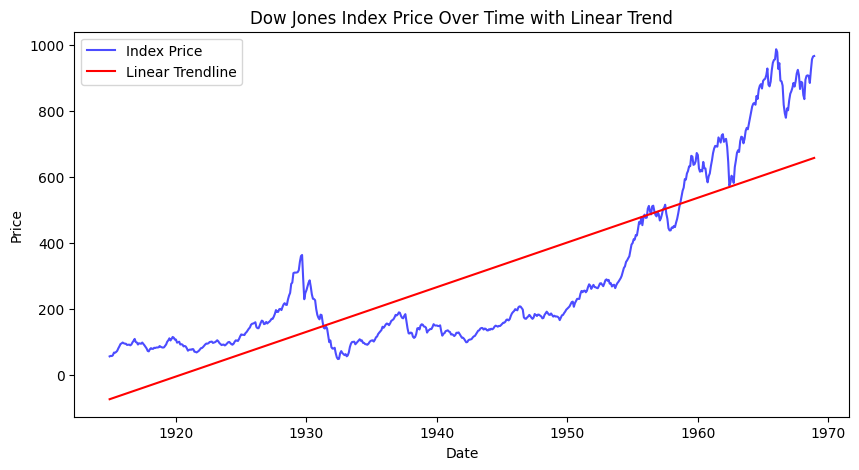

In [34]:
## Plotting time-series and trendline
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Price"], label = "Index Price", color="blue", alpha=0.7)
plt.plot(
    df["Date"],
    df["Trendline"],
    label="Linear Trendline",
    color="red",
    linestyle="-"
)
plt.title("Dow Jones Index Price Over Time with Linear Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [35]:
print(f"Pearson Correlation Coefficient(r): {r_value:.4f}")
print(f"R-squared (R^2): {r_squared:.4f}")

Pearson Correlation Coefficient(r): 0.8264
R-squared (R^2): 0.6829


#### Observations

1. High Pearson Correlation($r$) and ($R^2$) values demonstrate a strong overall trend in the time series.
2. Linear regression captures general growth, though actual prices show non-linear exponential behavior in recent decades.